### Persistence across sessions - Short term Memory

## SQLite Saver

In [ ]:
import sqlite3
import operator
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.sqlite import SqliteSaver

# 1. Define the State
class State(TypedDict):
    tasks: Annotated[list[str], operator.add]

# 2. Define the Logic
def task_manager(state: State):
    # This is a simple node that just processes the state
    return {"tasks": []} 

# . Setup the Graph
builder = StateGraph(State)
builder.add_node("manager", task_manager)
builder.add_edge(START, "manager")
builder.add_edge("manager", END)

#  Initialize SQLite Memory

conn = sqlite3.connect("task_memory1.db", check_same_thread=False)
memory = SqliteSaver(conn)

# 5. Compile with Checkpointer
graph = builder.compile(checkpointer=memory)

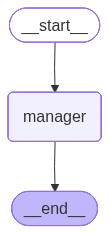

In [ ]:
graph

In [ ]:
config = {"configurable": {"thread_id": "user_123"}}
initial_input = {"tasks": ["Buy milk"]}

graph.invoke(initial_input, config)
# SQLite now contains: {"tasks": ["Buy milk"]} for thread user_123

{'tasks': ['Buy milk', 'Buy milk', 'Buy milk']}

In [ ]:
config = {"configurable": {"thread_id": "user_123"}}
initial_input = {"tasks": ["Buy milk"]}

graph.invoke(initial_input, config)

{'tasks': ['Buy milk', 'Buy milk', 'Buy milk', 'Buy milk']}

#### Example 2 : Persistance With SQLiteSaver CheckPointer

Design a simple troubleshooting chatbot that assists users with basic device issues by guiding them through a series of steps. The chatbot should be able to:

**Report User Issue:** The bot asks the user to describe the issue they are facing. Based on the issue reported, the bot provides initial troubleshooting steps such as checking the device's power or restarting it.

**Track Issue Resolution:** After offering troubleshooting steps, the bot monitors the number of interactions with the user:

    If more than 3 messages are exchanged, the bot assumes the issue may be more complex and suggests the user either try advanced troubleshooting or contact support.

    If fewer than 3 messages are exchanged, the bot assumes the issue is resolved and asks the user to confirm if their device is functioning properly.

**Key Features:**

Persistent conversation state using SQLite to store and load user issues and progress across sessions.

    A logical flow for offering initial troubleshooting steps and escalating or resolving issues based on the conversation length.

In [ ]:
#!pip install langgraph-checkpoint-sqlite 

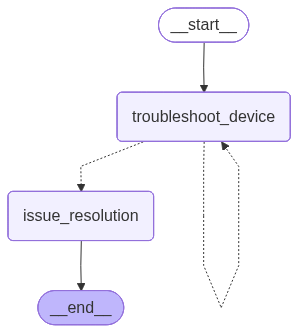

In [ ]:
import sqlite3
conn = sqlite3.connect('support_chat_3.db', check_same_thread=False)

from langgraph.checkpoint.sqlite import SqliteSaver

memory = SqliteSaver(conn)

from langgraph.graph import MessagesState, START, END

from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.redis import RedisSaver

# Initialize Bedrock LLM
llm = ChatBedrockConverse(
    model_id="anthropic.claude-3-sonnet-20240229-v1:0", #"amazon.nova-lite-v1:0", 
    region_name="us-east-1", 
    temperature=0.2,
    max_tokens=300
)

class State(MessagesState):
    issue_reported: str
    troubleshooting_steps: list
    resolution: str

from langchain_core.messages import SystemMessage, RemoveMessage, HumanMessage

def troubleshoot_device(state: State) -> State:
    """Guide the user through troubleshooting steps based on their reported issue."""
    
    issue = state.get("issue_reported")
    
    if issue:
        sys_msg = f"""The user has reported the following issue: {issue}
        
        Your task is to suggest troubleshooting steps. Please guide the user step-by-step.
        1. Start with the most common troubleshooting steps in 3 steps.
        2. Adjust the steps based on the user's responses.
        3. If the issue persists, escalate the issue to the next tier (or provide alternative solutions)."""
    else:
        sys_msg = """Please ask the user to describe the issue they are experiencing with their device.
        Based on their response, provide step-by-step troubleshooting guidance."""

    message = state["messages"] + [HumanMessage(content=sys_msg)]
    response = llm.invoke(message)
    
    # Track troubleshooting steps provided to the user
    updated_steps = state.get("troubleshooting_steps", [])
    updated_steps.append(response.content)
    
    return {
        "messages": state["messages"],
        "troubleshooting_steps": updated_steps
    }

def issue_resolution(state: State) -> State:
    """When the issue is resolved, provide a resolution and end the conversation."""
    
    steps = state.get("troubleshooting_steps", [])
    
    if len(steps) > 3:  # If more than 3 steps were taken
        sys_msg = """The issue seems complex. Please suggest an advanced solution or escalate the issue."""
    else:
        sys_msg = """The issue seems to have been resolved. Confirm with the user that their device is working properly."""
    
    message = state["messages"] + [SystemMessage(sys_msg)]
    response = llm.invoke(message)
    
    return {
        "messages": state["messages"] + [response],
        "resolution": response.content
    }


def should_continue(state: State) -> str:
    """Decides whether to continue troubleshooting or resolve the issue."""
    
    steps = state.get("troubleshooting_steps", [])
    
    # Continue troubleshooting if there are fewer than 2 steps
    if len(steps) < 4:
        return "troubleshoot_device"
    
    # Otherwise, resolve the issue
    return "issue_resolution"

# Create the state machine and add nodes/edges
builder = StateGraph(State)

builder.add_node("troubleshoot_device", troubleshoot_device)
builder.add_node("issue_resolution", issue_resolution)

builder.add_edge(START, "troubleshoot_device")
builder.add_conditional_edges("troubleshoot_device", 
                              should_continue,
                             {
                                 "troubleshoot_device":"troubleshoot_device",
                                 "issue_resolution":"issue_resolution"
                             })
builder.add_edge("issue_resolution", END)

# Compile the graph with state persistence
graph = builder.compile(checkpointer=memory)
graph

In [ ]:
config={"configurable":{"thread_id":"dec_7"}}

In [ ]:

# Start by prompting the user for their first query

while True:
    user_input = input("Enter your query (or type 'exit' to quit): ")
    if user_input=="exit":
        break
    for message in graph.stream({"messages":[HumanMessage(content=user_input)]},config=config):
        print("message:",message)

Enter your query (or type 'exit' to quit):  Hi


09:29:41 langchain_aws.chat_models.bedrock_converse INFO   Using Bedrock Converse API to generate response


message:
{
    'troubleshoot_device': {
        'messages': [
            HumanMessage(
                content='Hi',
                additional_kwargs={},
                response_metadata={},
                id='eb83f5b9-b949-4afb-87d8-75237bd5d088'
            )
        ],
        'troubleshooting_steps': [
            "Hi there! I'll be happy to help you troubleshoot the issue you're experiencing with your device. Could
you please describe the problem in detail? What kind of device is it, and what exactly is happening or not 
happening as expected? The more information you can provide, the better I can assist you with step-by-step guidance
to resolve the issue."
        ]
    }
}

09:29:43 langchain_aws.chat_models.bedrock_converse INFO   Using Bedrock Converse API to generate response


message:
{
    'troubleshoot_device': {
        'messages': [
            HumanMessage(
                content='Hi',
                additional_kwargs={},
                response_metadata={},
                id='eb83f5b9-b949-4afb-87d8-75237bd5d088'
            )
        ],
        'troubleshooting_steps': [
            "Hi there! I'll be happy to help you troubleshoot the issue you're experiencing with your device. Could
you please describe the problem in detail? What kind of device is it, and what exactly is happening or not 
happening as expected? The more information you can provide, the better I can assist you with step-by-step guidance
to resolve the issue.",
            "Hi there! I'll be happy to help you troubleshoot the issue you're experiencing with your device. Could
you please describe the problem in detail? What exactly is happening, and what steps have you already tried to 
resolve it? Please provide as much information as possible so that I can better understand the situation and 
provide appropriate troubleshooting steps."
        ]
    }
}

...

09:29:46 langchain_aws.chat_models.bedrock_converse INFO   Using Bedrock Converse API to generate response


message:
{
    'troubleshoot_device': {
        'messages': [
            HumanMessage(
                content='Hi',
                additional_kwargs={},
                response_metadata={},
                id='eb83f5b9-b949-4afb-87d8-75237bd5d088'
            )
        ],
        'troubleshooting_steps': [
            "Hi there! I'll be happy to help you troubleshoot the issue you're experiencing with your device. Could
you please describe the problem in detail? What kind of device is it, and what exactly is happening or not 
happening as expected? The more information you can provide, the better I can assist you with step-by-step guidance
to resolve the issue.",
            "Hi there! I'll be happy to help you troubleshoot the issue you're experiencing with your device. Could
you please describe the problem in detail? What exactly is happening, and what steps have you already tried to 
resolve it? Please provide as much information as possible so that I can better understand the situation and 
provide appropriate troubleshooting steps.",
            "Hello! I'll be happy to provide troubleshooting guidance for your device issue. Could you please 
describe the problem you're experiencing with your device in detail? Please provide as much information as 
possible, such as the type of device, any error messages you're seeing, or any specific symptoms or behaviors that 
concern you. The more details you can provide, the better I can assist you in resolving the issue.",
            "Hi there! I'll be happy to help you troubleshoot the issue you're experiencing with your device. Could
you please describe the problem in detail? What exactly is happening, and when did it start occurring? Please 
provide as much information as possible so that I can better understand the situation and provide appropriate 
troubleshooting steps."
        ]
    }
}

09:29:48 langchain_aws.chat_models.bedrock_converse INFO   Using Bedrock Converse API to generate response


message:
{
    'issue_resolution': {
        'messages': [
            HumanMessage(
                content='Hi',
                additional_kwargs={},
                response_metadata={},
                id='eb83f5b9-b949-4afb-87d8-75237bd5d088'
            ),
            AIMessage(
                content='Hello! How can I assist you today?',
                additional_kwargs={},
                response_metadata={
                    'ResponseMetadata': {
                        'RequestId': '16ce9623-530f-4f8a-94b5-d95e3693e987',
                        'HTTPStatusCode': 200,
                        'HTTPHeaders': {
                            'date': 'Mon, 08 Dec 2025 09:29:48 GMT',
                            'content-type': 'application/json',
                            'content-length': '236',
                            'connection': 'keep-alive',
                            'x-amzn-requestid': '16ce9623-530f-4f8a-94b5-d95e3693e987'
                        },
                        'RetryAttempts': 0
                    },
                    'stopReason': 'end_turn',
                    'metrics': {'latencyMs': [340]},
                    'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
                },
                id='run--f8706aa9-c03d-4152-9b8d-20c11cb6ac55-0',
                usage_metadata={
                    'input_tokens': 24,
                    'output_tokens': 12,
                    'total_tokens': 36,
                    'input_token_details': {'cache_creation': 0, 'cache_read': 0}
                }
            )
        ],
        'resolution': 'Hello! How can I assist you today?'
    }
}

Enter your query (or type 'exit' to quit):  exit


In [ ]:
from rich import print
print(graph.get_state(config))

StateSnapshot(
    values={
        'messages': [
            HumanMessage(
                content='Hi',
                additional_kwargs={},
                response_metadata={},
                id='eb83f5b9-b949-4afb-87d8-75237bd5d088'
            ),
            AIMessage(
                content='Hello! How can I assist you today?',
                additional_kwargs={},
                response_metadata={
                    'ResponseMetadata': {
                        'RequestId': '16ce9623-530f-4f8a-94b5-d95e3693e987',
                        'HTTPStatusCode': 200,
                        'HTTPHeaders': {
                            'date': 'Mon, 08 Dec 2025 09:29:48 GMT',
                            'content-type': 'application/json',
                            'content-length': '236',
                            'connection': 'keep-alive',
                            'x-amzn-requestid': '16ce9623-530f-4f8a-94b5-d95e3693e987'
                        },
                        'RetryAttempts': 0
                    },
                    'stopReason': 'end_turn',
                    'metrics': {'latencyMs': [340]},
                    'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
                },
                id='run--f8706aa9-c03d-4152-9b8d-20c11cb6ac55-0',
                usage_metadata={
                    'input_tokens': 24,
                    'output_tokens': 12,
                    'total_tokens': 36,
                    'input_token_details': {'cache_creation': 0, 'cache_read': 0}
                }
            )
        ],
        'troubleshooting_steps': [
            "Hi there! I'll be happy to help you troubleshoot the issue you're experiencing with your device. Could
you please describe the problem in detail? What kind of device is it, and what exactly is happening or not 
happening as expected? The more information you can provide, the better I can assist you with step-by-step guidance
to resolve the issue.",
            "Hi there! I'll be happy to help you troubleshoot the issue you're experiencing with your device. Could
you please describe the problem in detail? What exactly is happening, and what steps have you already tried to 
resolve it? Please provide as much information as possible so that I can better understand the situation and 
provide appropriate troubleshooting steps.",
            "Hello! I'll be happy to provide troubleshooting guidance for your device issue. Could you please 
describe the problem you're experiencing with your device in detail? Please provide as much information as 
possible, such as the type of device, any error messages you're seeing, or any specific symptoms or behaviors that 
concern you. The more details you can provide, the better I can assist you in resolving the issue.",
            "Hi there! I'll be happy to help you troubleshoot the issue you're experiencing with your device. Could
you please describe the problem in detail? What exactly is happening, and when did it start occurring? Please 
provide as much information as possible so that I can better understand the situation and provide appropriate 
troubleshooting steps."
        ],
        'resolution': 'Hello! How can I assist you today?'
    },
    next=(),
    config={
        'configurable': {
            'thread_id': 'dec_7',
            'checkpoint_ns': '',
            'checkpoint_id': '1f0d4187-0fb4-6947-8005-83de8ac014ec'
        }
    },
    metadata={'source': 'loop', 'step': 5, 'parents': {}},
    created_at='2025-12-08T09:29:48.830525+00:00',
    parent_config={
        'configurable': {
            'thread_id': 'dec_7',
            'checkpoint_ns': '',
            'checkpoint_id': '1f0d4187-0a7a-6bb4-8004-5ee6b3dcb3e0'
        }
    },
    tasks=(),
    interrupts=()
)